In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pylab as plt

from lightning import Trainer
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset

from dal_toolbox.models.laplace import LaplaceLinear, LaplaceModel

import logging
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


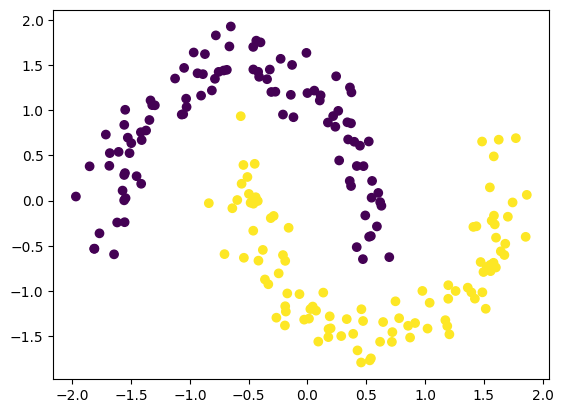

In [2]:
X, y = make_moons(n_samples=200, noise=.1, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()
dataset = TensorDataset(X, y)

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show()

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 50)
        self.layer2 = LaplaceLinear(50, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        features = self.forward_features(x)
        logits = self.forward_logits(features)
        return logits

    def forward_features(self, x):
        features = self.act(self.layer1(x))
        return features

    def forward_logits(self, features):
        logits = self.layer2(features)
        return logits
    
        

In [4]:
def build_model():
    model = Net()
    optimizer = torch.optim.RAdam(model.parameters(), lr=1e-1, weight_decay=1e-4)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=200)
    model = LaplaceModel(model, loss_fn=nn.CrossEntropyLoss(), optimizer=optimizer, lr_scheduler=lr_scheduler)
    return model

trainer_kwargs = dict(
    max_epochs=200,
    enable_checkpointing=False,
    logger=False,
    barebones=True,
)
model = build_model()
trainer = Trainer(**trainer_kwargs)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
trainer.fit(model, train_loader)

In [5]:
def plot_decision_boundary(model: LaplaceModel,  trainer, domain = 2.5):
    xx, yy = torch.meshgrid(torch.linspace(-domain, domain, 101), torch.linspace(-domain, domain, 201))
    zz = torch.stack((xx.ravel(), yy.ravel()), dim=1)

    model.predict_type = 'deterministic'
    predictions = trainer.predict(model, DataLoader(TensorDataset(zz, zz), batch_size=256))
    logits = torch.cat([pred[0] for pred in predictions])
    probas = logits.softmax(-1)[:, 1]

    plt.figure(figsize=(4, 3))
    plt.contour(xx, yy, probas.reshape(xx.shape), levels=[0.5], colors='k')
    plt.contourf(xx, yy, probas.reshape(xx.shape), cmap='coolwarm', levels=np.linspace(0, 1, 11), alpha=.8)


In [6]:
class DecisionFlips():
    def __init__(self, subset_size=None):
        super().__init__()
        self.subset_size = subset_size

    def query(self, *, model, al_datamodule, acq_size, **kwargs):
        unlabeled_dataloader, unlabeled_indices = al_datamodule.unlabeled_dataloader(subset_size=self.subset_size)
        labeled_dataloader, _ = al_datamodule.labeled_dataloader()

        features_unlabeled = model.get_representations(unlabeled_dataloader)
        features_labeled = model.get_representations(labeled_dataloader)

        # get representations of unlabeled pool


Seed set to 42


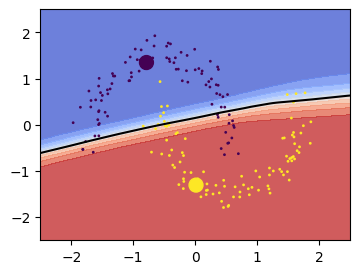

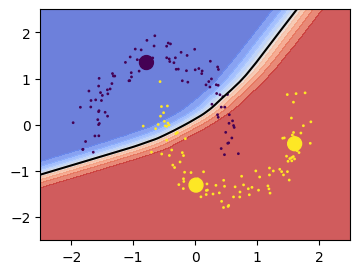

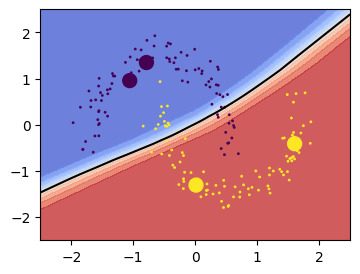

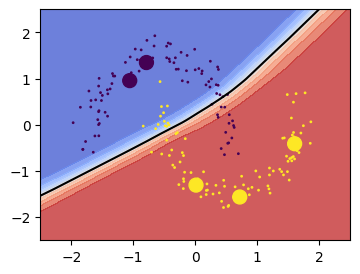

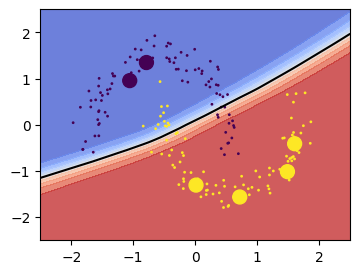

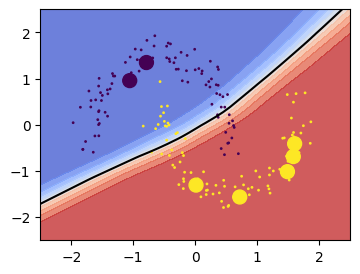

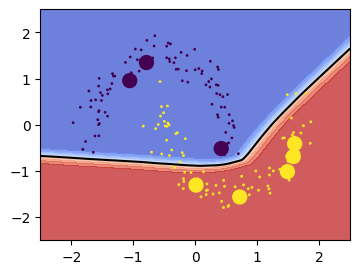

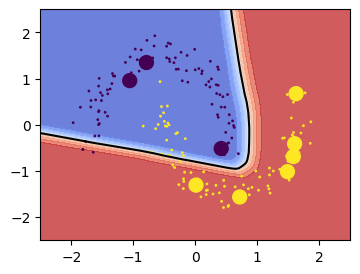

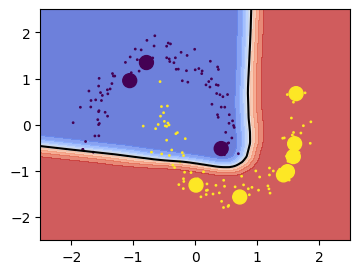

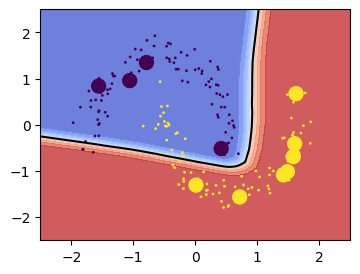

In [8]:
from dal_toolbox.active_learning import ActiveLearningDataModule
from dal_toolbox.active_learning.strategies import RandomSampling
from dal_toolbox.utils import seed_everything

seed_everything(42)

al_dm = ActiveLearningDataModule(dataset)
al_dm.random_init(2, class_balanced=True)
al_strat = RandomSampling()

for i in range(10):
    if i != 0:
        # TODO query
        indices = al_strat.query(al_datamodule=al_dm, acq_size=1)
        al_dm.update_annotations(indices)
        pass

    model = build_model()
    trainer = Trainer(**trainer_kwargs)
    trainer.fit(model, al_dm.train_dataloader())

    plot_decision_boundary(model, trainer)
    plt.scatter(X[al_dm.labeled_indices, 0], X[al_dm.labeled_indices, 1], c=y[al_dm.labeled_indices], s=100)
    plt.scatter(X[al_dm.unlabeled_indices, 0], X[al_dm.unlabeled_indices, 1], c=y[al_dm.unlabeled_indices], s=1)
    plt.show()